# Predictive Analytics Using Historical Sales Data

## Project Objective

The objective of this project is to analyze historical sales data, identify trends and seasonal patterns, build a predictive model, evaluate its performance, and forecast future sales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Predictive_Analytics_Large_Historical_Sales.csv to Predictive_Analytics_Large_Historical_Sales.csv


In [3]:
df = pd.read_csv("Predictive_Analytics_Large_Historical_Sales.csv")

df.head()

,Date,Sales,Orders,Average_Order_Value
0,2021-01-01,86433,85,1016.86
1,2021-01-02,85402,79,1081.04
2,2021-01-03,93981,107,878.33
3,2021-01-04,90862,98,927.16
4,2021-01-05,78378,78,1004.85


## 1. Dataset Overview

The dataset contains daily historical sales information from 2021 to 2025. It includes sales, number of orders, and average order value.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1826
Number of columns: 4


In [5]:
df.columns

Index(['Date', 'Sales', 'Orders', 'Average_Order_Value'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 1826 non-null   object 
 1   Sales                1826 non-null   int64  
 2   Orders               1826 non-null   int64  
 3   Average_Order_Value  1826 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 57.2+ KB


In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 1826 non-null   datetime64[ns]
 1   Sales                1826 non-null   int64         
 2   Orders               1826 non-null   int64         
 3   Average_Order_Value  1826 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 57.2 KB


## 2. Data Cleaning

In [8]:
df.isnull().sum()

,0
Date,0
Sales,0
Orders,0
Average_Order_Value,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Date,Sales,Orders,Average_Order_Value
count,1826,1826.000000,1826.000000,1826.000000
mean,2023-07-02 12:00:00,334111.854874,353.218510,951.230668
min,2021-01-01 00:00:00,78378.000000,78.000000,703.980000
25%,2022-04-02 06:00:00,229797.500000,231.000000,896.695000
50%,2023-07-02 12:00:00,340234.000000,352.000000,952.105000
75%,2024-09-30 18:00:00,441835.750000,476.000000,1005.727500
max,2025-12-31 00:00:00,576710.000000,689.000000,1198.070000
std,NaN,136182.804970,146.683508,79.817575


In [11]:
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Sales,Orders,Average_Order_Value
0,2021-01-01,86433,85,1016.86
1,2021-01-02,85402,79,1081.04
2,2021-01-03,93981,107,878.33
3,2021-01-04,90862,98,927.16
4,2021-01-05,78378,78,1004.85


## 3. Exploratory Data Analysis

### Historical Sales Trend

The following visualization shows how daily sales changed over the historical period.

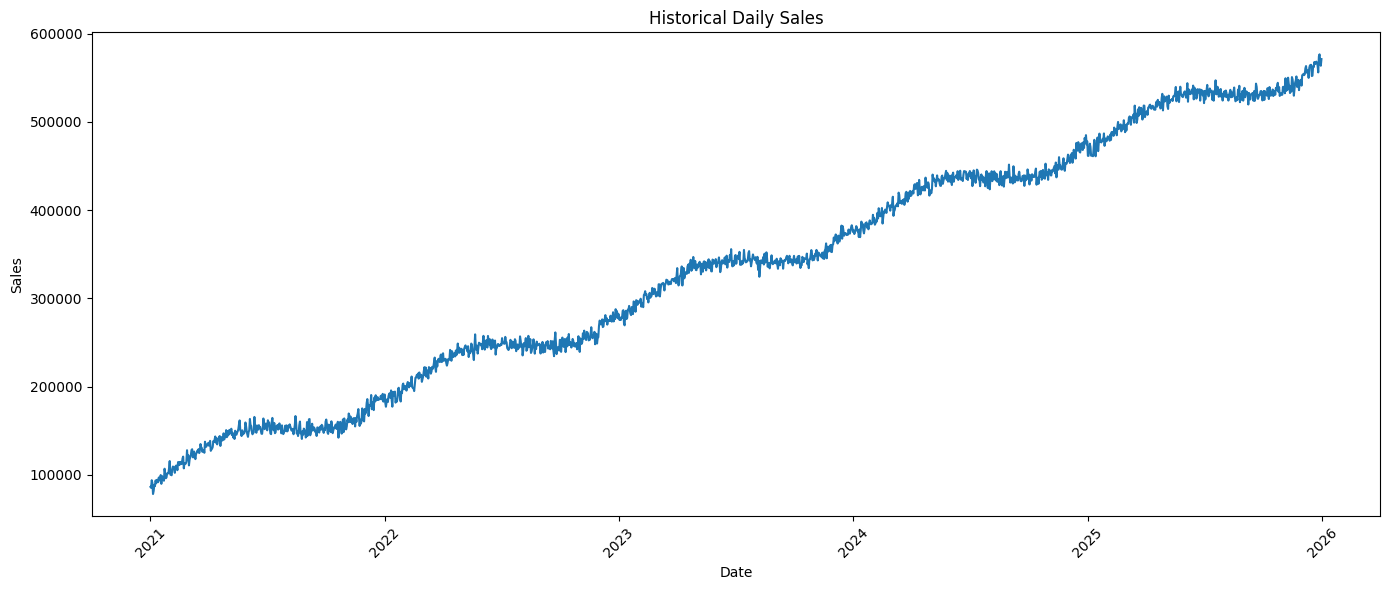

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Sales"])

plt.title("Historical Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
monthly_sales = df.resample(
    "MS",
    on="Date"
)["Sales"].sum().reset_index()

monthly_sales.head()

,Date,Sales
0,2021-01-01,2945769
1,2021-02-01,3110992
2,2021-03-01,3918270
3,2021-04-01,4164745
4,2021-05-01,4619634


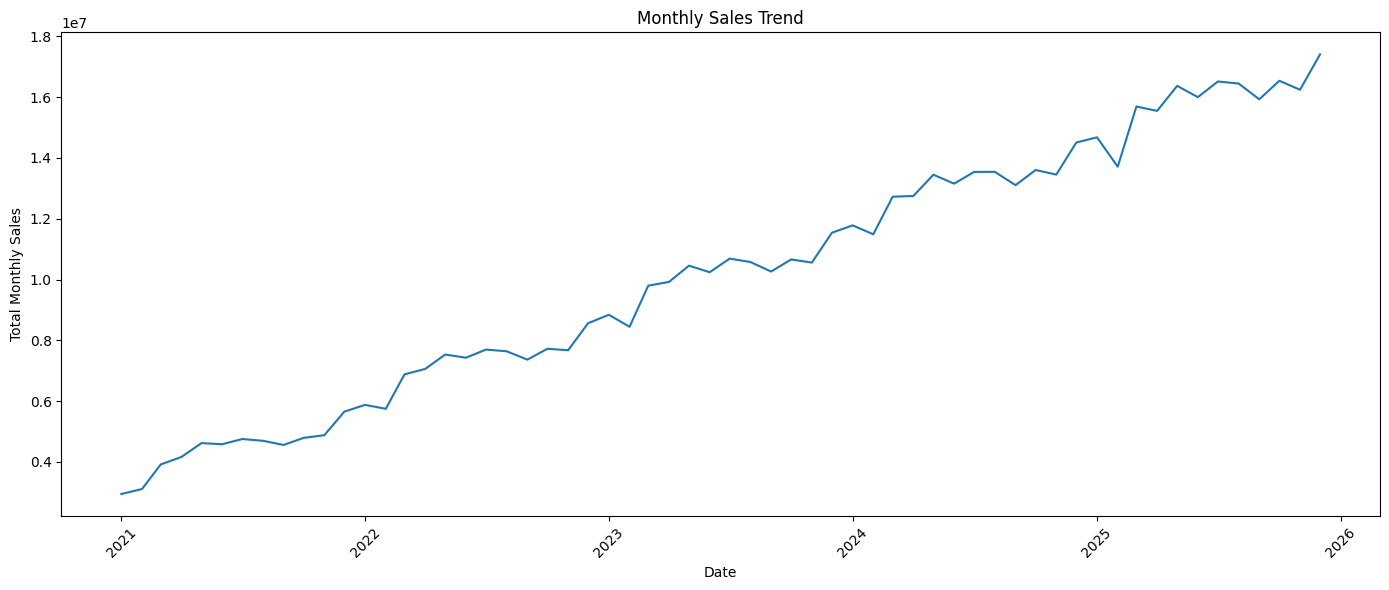

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
yearly_sales = df.groupby(
    df["Date"].dt.year
)["Sales"].sum()

yearly_sales

,Sales
Date,
2021,52681578
2022,87199258
2023,122001552
2024,157109252
2025,191096607


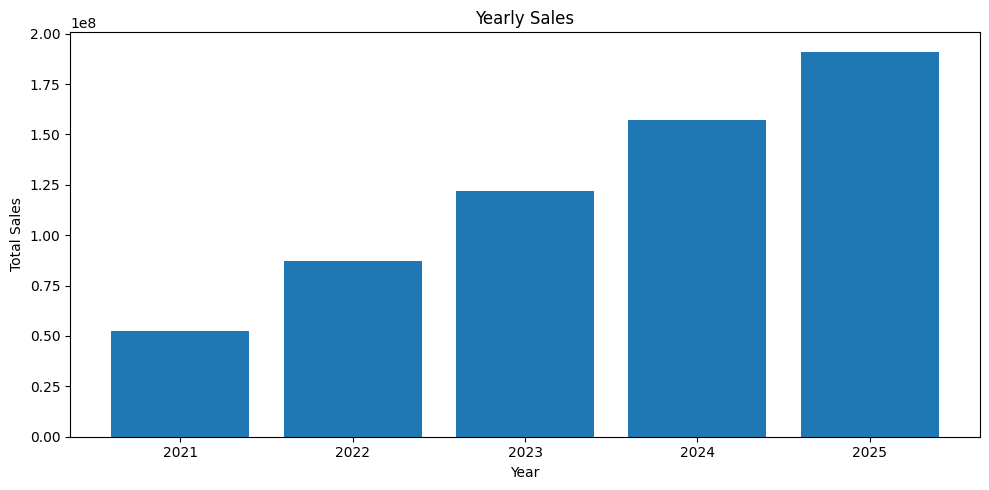

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values
)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

## 4. Feature Engineering

Date-related features are extracted from the historical data so that the machine learning model can learn trends and seasonal patterns.

In [17]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

df["Time_Index"] = np.arange(len(df))

df.head()

,Date,Sales,Orders,Average_Order_Value,Year,Month,Day,DayOfWeek,Time_Index
0,2021-01-01,86433,85,1016.86,2021,1,1,4,0
1,2021-01-02,85402,79,1081.04,2021,1,2,5,1
2,2021-01-03,93981,107,878.33,2021,1,3,6,2
3,2021-01-04,90862,98,927.16,2021,1,4,0,3
4,2021-01-05,78378,78,1004.85,2021,1,5,1,4


In [19]:
df["Month_Sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

df["Month_Cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)

In [20]:
df["DayOfWeek_Sin"] = np.sin(
    2 * np.pi * df["DayOfWeek"] / 7
)

df["DayOfWeek_Cos"] = np.cos(
    2 * np.pi * df["DayOfWeek"] / 7
)

In [21]:
df.head()

,Date,Sales,Orders,Average_Order_Value,Year,Month,Day,DayOfWeek,Time_Index,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos
0,2021-01-01,86433,85,1016.86,2021,1,1,4,0,0.5,0.866025,-0.433884,-0.900969
1,2021-01-02,85402,79,1081.04,2021,1,2,5,1,0.5,0.866025,-0.974928,-0.222521
2,2021-01-03,93981,107,878.33,2021,1,3,6,2,0.5,0.866025,-0.781831,0.623490
3,2021-01-04,90862,98,927.16,2021,1,4,0,3,0.5,0.866025,0.000000,1.000000
4,2021-01-05,78378,78,1004.85,2021,1,5,1,4,0.5,0.866025,0.781831,0.623490


In [22]:
features = [
    "Time_Index",
    "Month_Sin",
    "Month_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos"
]

X = df[features]
y = df["Sales"]

In [23]:
train_data = df[df["Date"] < "2025-01-01"]
test_data = df[df["Date"] >= "2025-01-01"]

X_train = train_data[features]
y_train = train_data["Sales"]

X_test = test_data[features]
y_test = test_data["Sales"]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 1461
Testing records: 365


## 5. Predictive Model

Linear Regression is used to model the relationship between historical time-based features and sales. The model learns the underlying trend and seasonal patterns from the training data.

In [24]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [25]:
y_pred = model.predict(X_test)

y_pred[:10]

array([470815.47473862, 471953.13181789, 474107.341816  , 475852.28349954,
       476070.32302357, 474793.61501236, 473179.88947151, 472640.65748036,
       473778.31455964, 475932.52455774])

In [26]:
results = pd.DataFrame({
    "Date": test_data["Date"].values,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred.round(2)
})

results.head(10)

,Date,Actual_Sales,Predicted_Sales
0,2025-01-01,461661,470815.47
1,2025-01-02,461600,471953.13
2,2025-01-03,468033,474107.34
3,2025-01-04,475438,475852.28
4,2025-01-05,471699,476070.32
5,2025-01-06,461759,474793.62
6,2025-01-07,461960,473179.89
7,2025-01-08,462195,472640.66
8,2025-01-09,461201,473778.31
9,2025-01-10,470188,475932.52


## 6. Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [27]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 4671.66
Root Mean Squared Error (RMSE): 5798.45
R² Score: 0.9384


## 7. Actual vs Predicted Sales

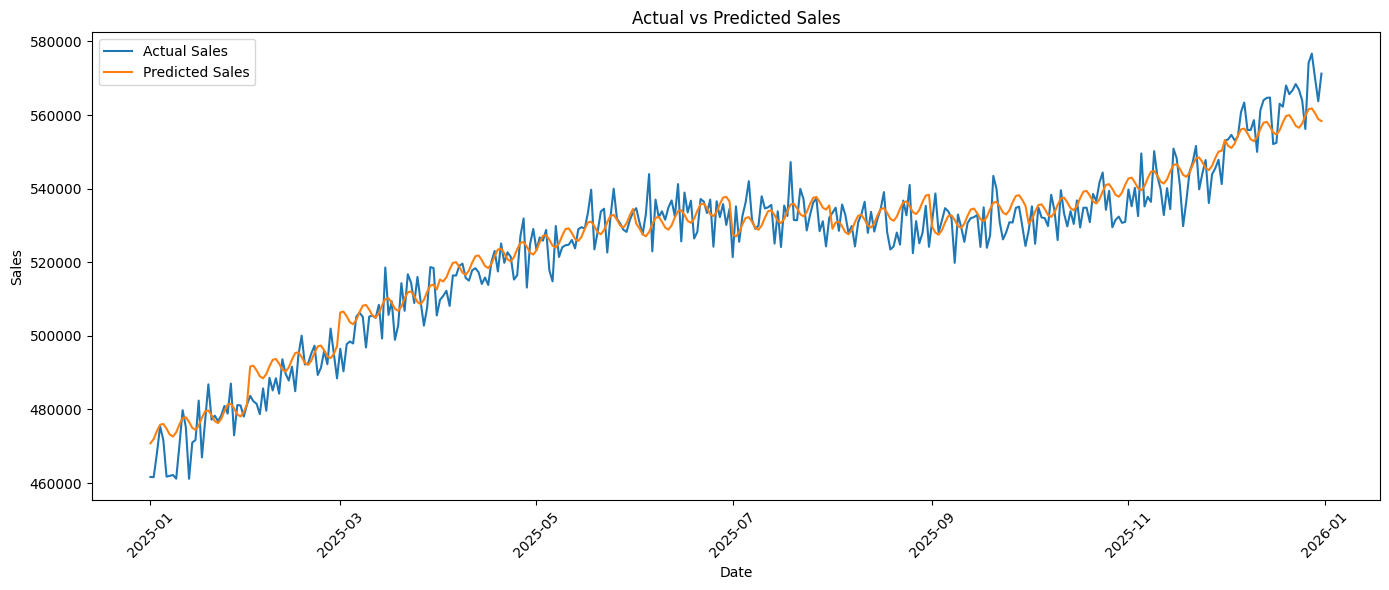

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    results["Date"],
    results["Actual_Sales"],
    label="Actual Sales"
)

plt.plot(
    results["Date"],
    results["Predicted_Sales"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
accuracy = 100 - (
    mean_absolute_error(y_test, y_pred) /
    y_test.mean() * 100
)

print("Approximate Prediction Accuracy:",
      round(accuracy, 2), "%")

Approximate Prediction Accuracy: 99.11 %


## 8. Future Sales Forecast

The trained model is used to forecast sales for the next 90 days after the historical period.

In [31]:
future_dates = pd.date_range(
    start="2026-01-01",
    periods=90,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates
})

future_df["Month"] = future_df["Date"].dt.month
future_df["DayOfWeek"] = future_df["Date"].dt.dayofweek

future_df["Time_Index"] = np.arange(
    len(df),
    len(df) + len(future_df)
)

In [32]:
future_df["Month_Sin"] = np.sin(
    2 * np.pi * future_df["Month"] / 12
)

future_df["Month_Cos"] = np.cos(
    2 * np.pi * future_df["Month"] / 12
)

future_df["DayOfWeek_Sin"] = np.sin(
    2 * np.pi * future_df["DayOfWeek"] / 7
)

future_df["DayOfWeek_Cos"] = np.cos(
    2 * np.pi * future_df["DayOfWeek"] / 7
)

In [33]:
future_X = future_df[features]

future_df["Forecasted_Sales"] = model.predict(
    future_X
).round(2)

future_df.head(10)

,Date,Month,DayOfWeek,Time_Index,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos,Forecasted_Sales
0,2026-01-01,1,3,1826,0.5,0.866025,0.433884,-0.900969,566862.63
1,2026-01-02,1,4,1827,0.5,0.866025,-0.433884,-0.900969,569016.84
2,2026-01-03,1,5,1828,0.5,0.866025,-0.974928,-0.222521,570761.79
3,2026-01-04,1,6,1829,0.5,0.866025,-0.781831,0.623490,570979.83
4,2026-01-05,1,0,1830,0.5,0.866025,0.000000,1.000000,569703.12
5,2026-01-06,1,1,1831,0.5,0.866025,0.781831,0.623490,568089.39
6,2026-01-07,1,2,1832,0.5,0.866025,0.974928,-0.222521,567550.16
7,2026-01-08,1,3,1833,0.5,0.866025,0.433884,-0.900969,568687.82
8,2026-01-09,1,4,1834,0.5,0.866025,-0.433884,-0.900969,570842.03
9,2026-01-10,1,5,1835,0.5,0.866025,-0.974928,-0.222521,572586.97


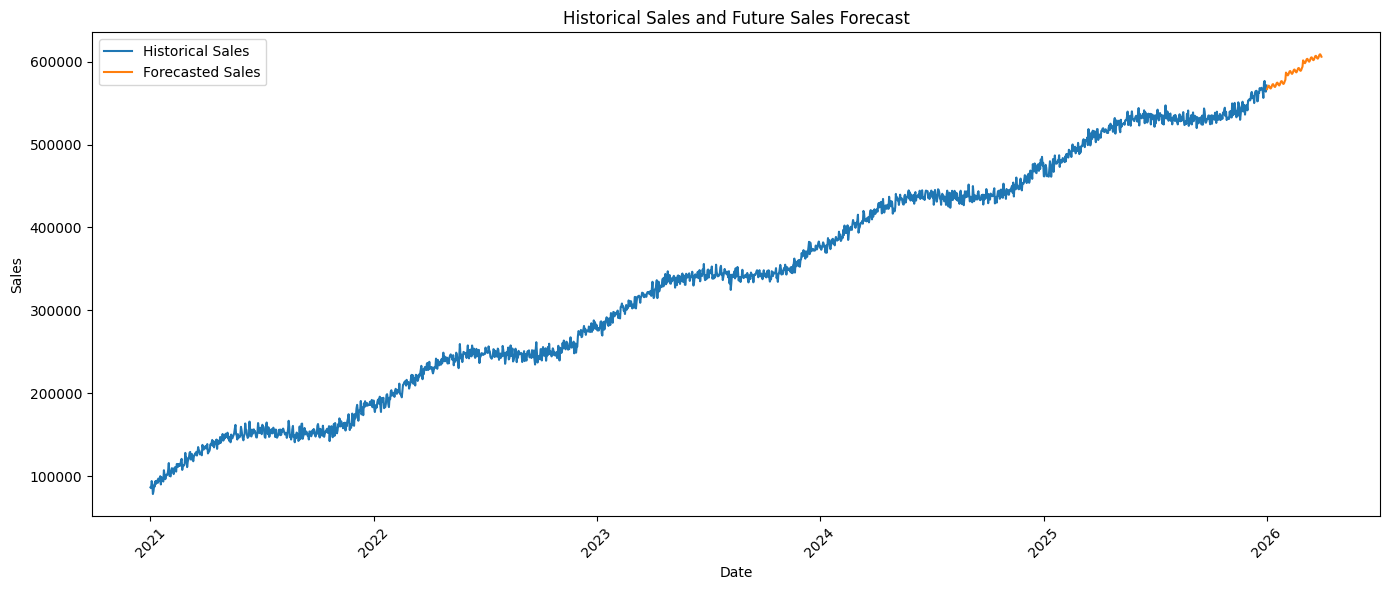

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_df["Date"],
    future_df["Forecasted_Sales"],
    label="Forecasted Sales"
)

plt.title(
    "Historical Sales and Future Sales Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
highest = future_df.loc[
    future_df["Forecasted_Sales"].idxmax()
]

print(
    "Highest Forecasted Date:",
    highest["Date"].strftime("%d %B %Y")
)

print(
    "Forecasted Sales:",
    highest["Forecasted_Sales"]
)

Highest Forecasted Date: 29 March 2026
Forecasted Sales: 608810.95


In [36]:
lowest = future_df.loc[
    future_df["Forecasted_Sales"].idxmin()
]

print(
    "Lowest Forecasted Date:",
    lowest["Date"].strftime("%d %B %Y")
)

print(
    "Forecasted Sales:",
    lowest["Forecasted_Sales"]
)

Lowest Forecasted Date: 01 January 2026
Forecasted Sales: 566862.63


In [37]:
future_monthly = future_df.copy()

future_monthly["Month_Name"] = (
    future_monthly["Date"].dt.strftime("%B")
)

monthly_forecast = future_monthly.groupby(
    "Month_Name",
    sort=False
)["Forecasted_Sales"].sum()

monthly_forecast

,Forecasted_Sales
Month_Name,
January,17737056.18
February,16473401.28
March,18707531.72


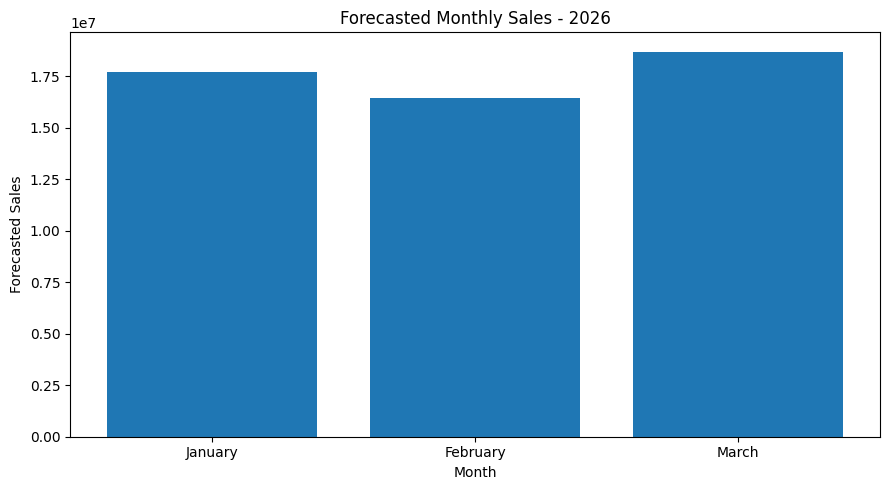

In [38]:
plt.figure(figsize=(9, 5))

plt.bar(
    monthly_forecast.index,
    monthly_forecast.values
)

plt.title("Forecasted Monthly Sales - 2026")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")

plt.tight_layout()
plt.show()

In [39]:
future_df.to_csv(
    "Sales_Forecast_2026.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


In [40]:
from google.colab import files

files.download("Sales_Forecast_2026.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 9. Project Findings

- The historical dataset contains 1,826 daily sales records covering 2021 to 2025.
- The data was checked for missing values and duplicate records.
- Date-based features were created to capture trends and seasonal patterns.
- Linear Regression was used as the predictive model.
- The model was trained using historical data from 2021 to 2024.
- The year 2025 was used as the testing period.
- Model performance was evaluated using MAE, RMSE and R² Score.
- Actual and predicted sales were visualized to evaluate the model.
- Future sales were forecast for the first 90 days of 2026.

# 10. Conclusion

This project demonstrates how predictive analytics can be applied to historical sales data to identify trends and forecast future sales. Historical data was cleaned and transformed into useful time-based features before training a Linear Regression model. The model was evaluated using multiple performance metrics and then used to forecast future sales. The results demonstrate how predictive analytics can support business planning, demand estimation and data-driven decision making.